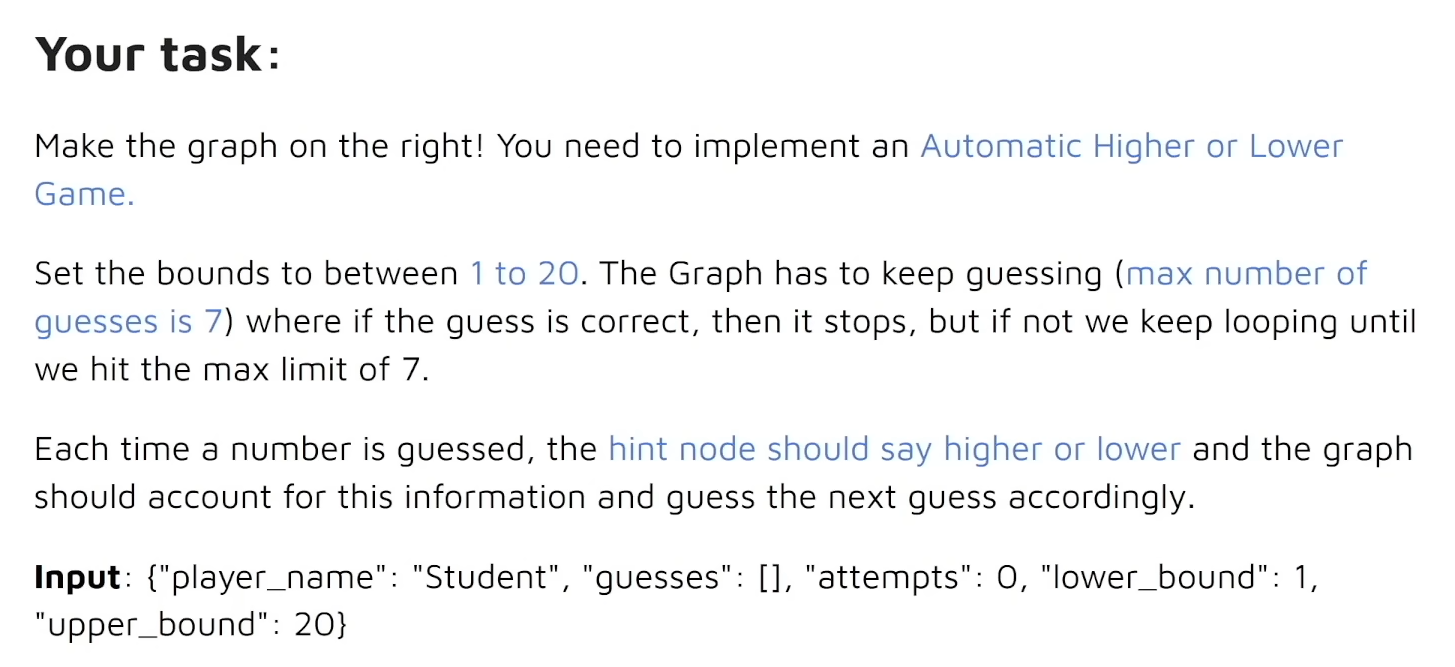

In [ ]:
!pip install langgraph

In [ ]:
from langgraph.graph import StateGraph,START,END
import random
from typing import List,Dict,TypedDict

In [ ]:
class AgentState(TypedDict):
  name:str
  target:int
  gvalue:int
  counter:int
  lb:int
  hb:int

In [ ]:
def greeting_node(state:AgentState) -> AgentState:
  """ greeting node which saysa hi """
  state["name"] = f"hi there,{state['name']}"
  state["counter"] = 0
  state['lb'] = 0
  state['hb'] = 20
  return state

def random_node(state:AgentState) -> AgentState:
  """ genrate a random number from 0 to 10"""
  state['gvalue'] = random.randint(state['lb'],state['hb'])
  state['counter'] += 1

  return state

def should_continue(state: AgentState) -> str:
    """Decide next step"""

    if state["counter"] < 7:

        if state["gvalue"] < state["target"]:
            print("higher", state["gvalue"])
            state["lb"] = state["gvalue"] + 1  # important +1
            return "loop"

        elif state["gvalue"] > state["target"]:
            print("lower", state["gvalue"])
            state["hb"] = state["gvalue"] - 1  # important -1
            return "loop"

        else:
            print("correct 🎯")
            return "exit"
    else:
        print("failed ❌")
        return "exit"


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeting",greeting_node)
graph.add_node("random",random_node)
graph.add_edge("greeting","random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop":"random",
          "exit":END
    }
)

graph.set_entry_point("greeting")

app = graph.compile()


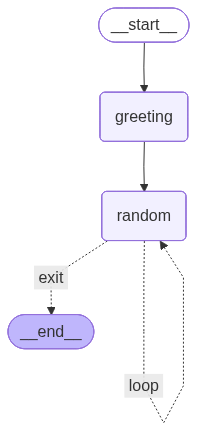

In [ ]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
app.invoke({"name" : "utkarsh",'target' : 4})

higher 0
lower 6
lower 14
lower 10
higher 2
lower 13
failed ❌


{'name': 'hi there,utkarsh',
 'target': 4,
 'gvalue': 10,
 'counter': 7,
 'lb': 0,
 'hb': 20}